In [1]:
!git clone https://github.com/faranbutt/OctoNode_Cup.git

Cloning into 'OctoNode_Cup'...
remote: Enumerating objects: 697, done.
remote: Counting objects: 100% (124/124), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 697 (delta 113), reused 73 (delta 73), pack-reused 573 (from 2)
Receiving objects: 100% (697/697), 6.13 MiB | 12.12 MiB/s, done.
Resolving deltas: 100% (344/344), done.


In [2]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 40.7 MB/s eta 0:00:00


In [3]:
from torch.optim.lr_scheduler import CosineAnnealingLR
import time
import platform
import pandas as pd
import numpy as np
import scipy.sparse as sp
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATv2Conv, GraphSAGE, SAGEConv,JumpingKnowledge
from torch_geometric.data import Data
from sklearn.preprocessing import StandardScaler
from torch_geometric.utils import (
    from_scipy_sparse_matrix,
    to_undirected,
    remove_self_loops,
    add_self_loops
)
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import f1_score,classification_report,confusion_matrix,accuracy_score
import copy

In [4]:
SEED = 25
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
  torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [6]:
print(f"Pytorch Version  = {torch.__version__}")
print(f"OS  = {platform.system()} {platform.release()}")
print(f"Processor = {platform.processor()}")

Pytorch Version  = 2.10.0+cu128
OS  = Linux 6.6.113+
Processor = x86_64


In [7]:
START_TIME = time.time()
START_TIME

1774098521.3599472

In [8]:
train_df = pd.read_csv('/content/OctoNode_Cup/data/public/train_target.csv')
train_df

,id,name,ml_target
0,0,Eiryyy,0
1,1,shawflying,0
2,2,JpMCarrilho,1
3,3,SuhwanCha,0
4,4,sunilangadi2,1
...,...,...,...
30154,30154,danielfm,0
30155,30155,filnik,0
30156,30156,chiqj,1
30157,30157,gjuchault,0


In [9]:
test_df = pd.read_csv('/content/OctoNode_Cup/data/public/test_target_without_labels.csv')
test_df

,id,name
0,30159,lmansur
1,30160,CodyHolmes
2,30161,rohitnairtech
3,30162,avwo
4,30163,godkun
...,...,...
7536,37695,shawnwanderson
7537,37696,kris-ipeh
7538,37697,qpautrat
7539,37698,Injabie3


In [10]:
edges = pd.read_csv('/content/OctoNode_Cup/data/public/musae_git_edges.csv')
edges

,id_1,id_2
0,0,23977
1,1,34526
2,1,2370
3,1,14683
4,1,29982
...,...,...
288998,37527,37596
288999,37529,37601
289000,37644,2347
289001,25879,2347


In [11]:
with np.load('/content/OctoNode_Cup/data/public/adjacency_matrix.npz', allow_pickle=True) as loader:
    matrix = sp.csr_matrix((loader['data'], loader['indices'], loader['indptr']),
                           shape=loader['shape'])
adj_df = pd.DataFrame(matrix.toarray())
adj_df

,0,1,2,3,4,5,6,7,8,9,...,37690,37691,37692,37693,37694,37695,37696,37697,37698,37699
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37695,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
37696,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
37697,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
37698,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [12]:
data_array = np.load('/content/OctoNode_Cup/data/public/node_features.npy',allow_pickle=True)
node_features = pd.DataFrame(data_array)
node_features

,0,1,2,3,4,5,6,7,8,9,...,32,33,34,35,36,37,38,39,40,41
0,1574.0,3773.0,3571.0,2672.0,2478.0,2534.0,3129.0,3077.0,1171.0,2045.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1193.0,376.0,73.0,290.0,3129.0,1852.0,3077.0,1171.0,1022.0,2045.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1574.0,3773.0,925.0,1728.0,2815.0,2963.0,3077.0,364.0,1171.0,536.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3964.0,3773.0,4003.0,928.0,1852.0,3077.0,364.0,1022.0,3763.0,2045.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1929.0,3773.0,1793.0,3511.0,1290.0,3129.0,3077.0,364.0,1171.0,1022.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37695,1574.0,3773.0,73.0,1995.0,3554.0,1233.0,1789.0,345.0,3129.0,1852.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
37696,1929.0,3773.0,1663.0,1404.0,508.0,819.0,1852.0,3077.0,364.0,1171.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
37697,3433.0,3773.0,3104.0,1245.0,3129.0,1852.0,3077.0,364.0,1171.0,3763.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
37698,3730.0,3773.0,1695.0,2092.0,2954.0,1852.0,3077.0,364.0,1171.0,1022.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
print(f'train_df shape = {train_df.shape}')
print(f'test_df shape = {test_df.shape}')
print(f'Edges shape = {edges.shape}')
print(f'Node Features shape = {node_features.shape}')
print(f'Adjancecy Matrix shape = {adj_df.shape}')

train_df shape = (30159, 3)
test_df shape = (7541, 2)
Edges shape = (289003, 2)
Node Features shape = (37700, 42)
Adjancecy Matrix shape = (37700, 37700)


In [14]:
print(f'Train columns = {train_df.columns.tolist()}')
print(f"Test columns = {test_df.columns.tolist()}")
print(f"Edges columns = {edges.columns.tolist()}")

Train columns = ['id', 'name', 'ml_target']
Test columns = ['id', 'name']
Edges columns = ['id_1', 'id_2']


In [15]:
num_nodes = node_features.shape[0]
num_feat = node_features.shape[1]
num_class = 2

In [16]:
train_ids = set(train_df['id'].values)
test_ids = set(test_df['id'].values)
len(train_ids & test_ids) == 0

True

In [17]:
class_counts = train_df['ml_target'].value_counts().sort_index()
print("Class Distribution:")
print(f"Class 0(ML Dev) = {class_counts[0]}")
print(f"Class 1(Web Dev) = {class_counts[1]}")
print(f"Imbalance Ratio = {class_counts.max() / class_counts.min():.2f}x")



Class Distribution:
Class 0(ML Dev) = 22383
Class 1(Web Dev) = 7776
Imbalance Ratio = 2.88x


# EDA

In [18]:
src = edges['id_1'].values
dst = edges['id_2'].values
G = nx.Graph()
G.add_nodes_from(range(num_nodes))
G.add_edges_from(zip(src,dst))

In [19]:
degrees = [d for _,d in G.degree()]
co = sorted(nx.connected_components(G),key=len,reverse=True)
cc_sizes = [len(c) for c in co]

In [20]:
print(f"Nodes = {G.number_of_nodes()}")
print(f"Edges  = {G.number_of_edges()}")
print(f"Self Loops = {nx.number_of_selfloops(G)}")
print(f'Is connected = {nx.is_connected(G)}')
print(f'Connected Comps = {len(co)}')
print(f'Largest comp size = {cc_sizes[0]:,}')

print(f"min degree = {min(degrees)}")
print(f"max degree = {max(degrees)}")
print(f"mean degree = {np.mean(degrees)}")
print(f"Median degree = {np.median(degrees)}")

Nodes = 37700
Edges  = 289003
Self Loops = 0
Is connected = True
Connected Comps = 1
Largest comp size = 37,700
min degree = 1
max degree = 9458
mean degree = 15.331724137931035
Median degree = 6.0


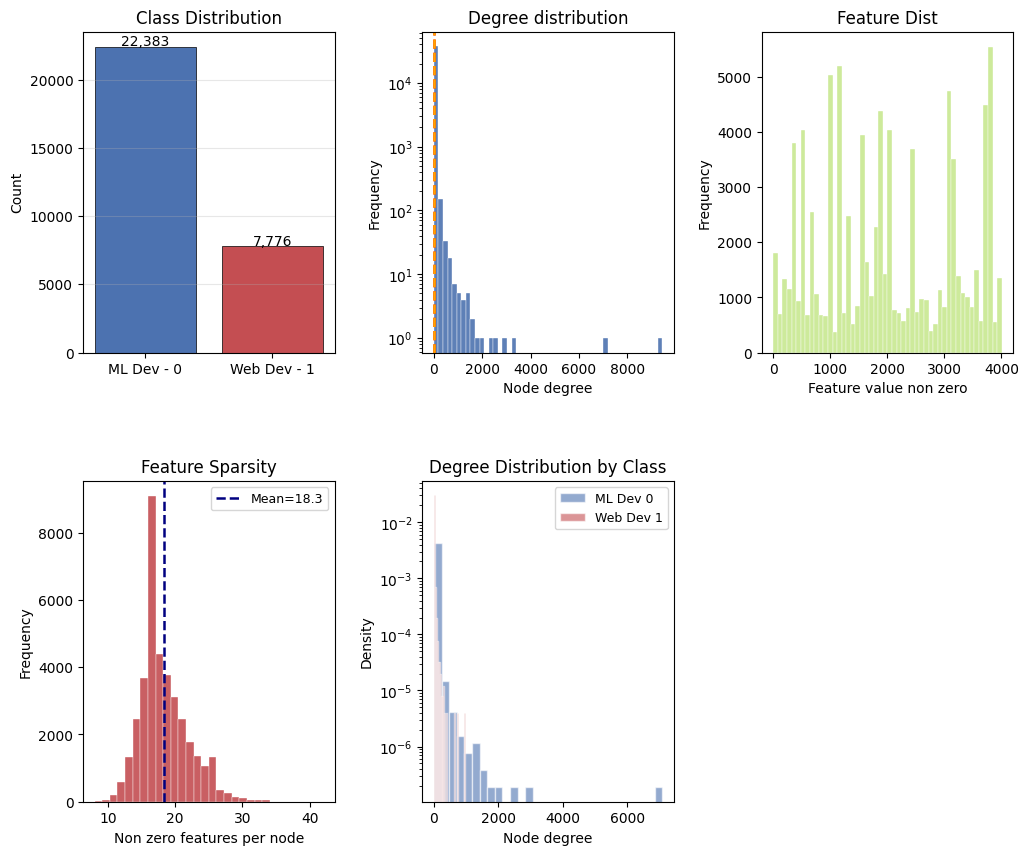

In [21]:
fig = plt.figure(figsize=(12,10))
g = gs.GridSpec(2,3,figure=fig,hspace=0.4,wspace=0.35)
ax1 = fig.add_subplot(g[0,0])
bars = ax1.bar(["ML Dev - 0","Web Dev - 1"],[class_counts[0],class_counts[1]],color=["#4C72B0", "#C44E52"], edgecolor="black", linewidth=0.5)
ax1.set_title('Class Distribution')
ax1.set_ylabel("Count")

for bar,cnt in zip(bars,[class_counts[0],class_counts[1]]):
  ax1.text(bar.get_x()+bar.get_width() / 2,bar.get_height()+100,f"{cnt:,}",ha='center',)
  ax1.grid(axis="y", alpha=0.3)

ax2 = fig.add_subplot(g[0,1])
ax2.hist(degrees,bins=50,color="#4C72B0", edgecolor="white",linewidth=0.3, alpha=0.9, log=True)
ax2.axvline(np.mean(degrees),color='red',linestyle='--',label=f"Mean",lw=1.8)
ax2.axvline(np.median(degrees),color='orange',linestyle='--',label=f'Median = {np.median(degrees):.2f}',lw=1.8)
ax2.set_xlabel("Node degree")
ax2.set_ylabel('Frequency')
ax2.set_title("Degree distribution")
ax3 = fig.add_subplot(g[0,2])
sample_feats = np.array(node_features[:5000]).flatten()
ax3.hist(sample_feats[sample_feats > 0],bins=50,color='#C8E890', edgecolor="white", linewidth=0.3, alpha=0.9)
ax3.set_xlabel("Feature value non zero")
ax3.set_ylabel('Frequency')
ax3.set_title("Feature Dist")

ax4 = fig.add_subplot(g[1,0])
nonzero_per_node = np.count_nonzero(node_features,axis=1)
ax4.hist(nonzero_per_node,bins=30,color="#C44E52",edgecolor="white", linewidth=0.3, alpha=0.9)
ax4.axvline(nonzero_per_node.mean(), color="navy", linestyle="--",lw=1.8, label=f"Mean={nonzero_per_node.mean():.1f}")
ax4.set_xlabel("Non zero features per node")
ax4.set_ylabel("Frequency")
ax4.set_title("Feature Sparsity")
ax4.legend(fontsize=9)

ax5 = fig.add_subplot(g[1,1])
train_degrees_0 = [G.degree(nid) for nid in train_df[train_df['ml_target'] == 0]['id'].values if nid in G]
train_degrees_1 = [G.degree(nid) for nid in train_df[train_df['ml_target'] == 1]['id'].values if nid in G]
ax5.hist(train_degrees_0,bins=30,label="ML Dev 0",alpha=0.6, color="#4C72B0", edgecolor="white", density=True)
ax5.hist(train_degrees_1,bins=30,label="Web Dev 1",alpha=0.6,color="#C44E52", edgecolor="white", density=True)
ax5.set_xlabel("Node degree")
ax5.set_ylabel("Density")
ax5.set_title("Degree Distribution by Class")
ax5.legend(fontsize=9)
ax5.set_yscale("log")
plt.show()



# Graph Construction

In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(node_features.astype(np.float32))
X_tensor = torch.FloatTensor(X_scaled)

In [23]:
train_df

,id,name,ml_target
0,0,Eiryyy,0
1,1,shawflying,0
2,2,JpMCarrilho,1
3,3,SuhwanCha,0
4,4,sunilangadi2,1
...,...,...,...
30154,30154,danielfm,0
30155,30155,filnik,0
30156,30156,chiqj,1
30157,30157,gjuchault,0


In [24]:
labels = np.full(num_nodes,-1,dtype=np.int64)
for i,row in train_df.iterrows():
  labels[int(row['id'])] = int(row['ml_target'])

y = torch.LongTensor(labels)

In [25]:
n_train = len(train_df)
n_val = int(n_train * 0.80)

In [26]:
train_node_ids = train_df['id'].values[:n_val]
val_node_ids = train_df['id'].values[n_val:]
test_node_ids = test_df['id'].values

In [27]:
train_mask = torch.zeros(num_nodes,dtype=torch.bool)
val_mask = torch.zeros(num_nodes,dtype=torch.bool)
test_mask = torch.zeros(num_nodes,dtype=torch.bool)

In [28]:
train_mask[torch.LongTensor(train_node_ids)] = True
val_mask[torch.LongTensor(val_node_ids)] = True
test_mask[torch.LongTensor(test_node_ids)] = True

In [29]:
print(f"Train Nodes = {train_mask.sum()}")
print(f"Val Nodes = {val_mask.sum()}")
print(f"Test Nodes = {test_mask.sum()}")

Train Nodes = 24127
Val Nodes = 6032
Test Nodes = 7541


In [30]:
src_arr = torch.LongTensor(edges['id_1'].values)
dst_arr = torch.LongTensor(edges['id_2'].values)

In [31]:
edge_index = torch.stack([src_arr,dst_arr],dim=0)
edge_index = to_undirected(edge_index,num_nodes=num_nodes)
edge_index,_ = remove_self_loops(edge_index)
f'Edge Index shape = {edge_index.shape} '

'Edge Index shape = torch.Size([2, 578006]) '

In [32]:
data = Data(x=X_tensor,y=y,edge_index=edge_index,train_mask=train_mask,val_mask=val_mask,test_mask=test_mask)
data.test_ids = torch.LongTensor(test_node_ids)
data.test_df = test_df.reset_index(drop=True)

In [33]:
data

Data(x=[37700, 42], edge_index=[2, 578006], y=[37700], train_mask=[37700], val_mask=[37700], test_mask=[37700], test_ids=[7541], test_df=         id            name
0     30159         lmansur
1     30160      CodyHolmes
2     30161   rohitnairtech
3     30162            avwo
4     30163          godkun
...     ...             ...
7536  37695  shawnwanderson
7537  37696       kris-ipeh
7538  37697        qpautrat
7539  37698        Injabie3
7540  37699   caseycavanagh

[7541 rows x 2 columns])

In [34]:
all_labeled_y = data.y[train_mask|val_mask]
counts= torch.bincount(all_labeled_y,minlength=2).float()
class_weights = counts.sum() / (2.0 * counts)
data.class_weights = class_weights

In [35]:
print(f"Class 0 - ML dev - n = {int(counts[0]):,} - w = {class_weights[0]:.3f}")
print(f"Class 1 - Web dev - n = {int(counts[1]):,} - w = {class_weights[1]:.3f}")

Class 0 - ML dev - n = 22,383 - w = 0.674
Class 1 - Web dev - n = 7,776 - w = 1.939


# MODELS

In [36]:
class GCN(nn.Module):
  def __init__(self,in_channels,hidden_channels,out_channels,dropout):
    super().__init__()
    self.dropout = dropout
    self.conv1 = GCNConv(in_channels,hidden_channels,cached=True,normalize=True)
    self.bn1 = nn.BatchNorm1d(hidden_channels)
    self.conv2 = GCNConv(hidden_channels,out_channels,cached=True,normalize=True)

  def forward(self,x,edge_index):
    x = self.conv1(x,edge_index)
    x = self.bn1(x)
    x = F.relu(x)
    x = F.dropout(x,p=self.dropout,training=self.training)
    return self.conv2(x,edge_index)
  def reset_parameters(self):
    self.conv1.reset_parameters()
    self.conv2.reset_parameters()
    self.bn1.reset_parameters()


In [37]:
class GAT(nn.Module):
  def __init__(self,in_dim,hidden_dim,out_dim,heads,dropout):
    super().__init__()
    self.dropout = dropout
    self.conv1 = GATv2Conv(in_dim,hidden_dim,heads=heads,dropout=dropout,concat=True)
    self.bn1 = nn.BatchNorm1d(hidden_dim * heads)
    self.conv2 = GATv2Conv(hidden_dim * heads, out_dim, heads=1,dropout=dropout,concat=False)

  def forward(self,x,edge_index):
    x = F.dropout(x,p=self.dropout,training=self.training)
    x = self.conv1(x,edge_index)
    x = self.bn1(x)
    x = F.elu(x)
    x = F.dropout(x,p=self.dropout,training=self.training)
    return self.conv2(x,edge_index)
  def reset_parameters(self):
    self.conv1.reset_parameters()
    self.conv2.reset_parameters()
    self.bn1.reset_parameters()

In [38]:
class GraphSAGE(nn.Module):
  def __init__(self,in_channels,hidden_channels,out_channels, num_layers, dropout):
    super().__init__()
    self.dropout=dropout
    self.convs = nn.ModuleList()
    self.bns = nn.ModuleList()
    self.convs.append(SAGEConv(in_channels,hidden_channels))
    self.bns.append(nn.BatchNorm1d(hidden_channels))

    for _ in range(num_layers - 2):
      self.convs.append(SAGEConv(hidden_channels,hidden_channels))
      self.bns.append(nn.BatchNorm1d(hidden_channels))

    self.convs.append(SAGEConv(hidden_channels,out_channels))
  def forward(self,x,edge_index):
    for conv,bn in zip(self.convs[:-1],self.bns):
      x = conv(x,edge_index)
      x = F.relu(bn(x))
      x = F.dropout(x,p=self.dropout,training=self.training)
    return self.convs[-1](x,edge_index)
  def reset_parameters(self):
    for c in self.convs:
      c.reset_parameters()
    for b in self.bns:
      b.reset_parameters()

In [39]:
class JKNet(nn.Module):
  def __init__(self, in_dim, hidden_dim=128, out_dim=2,
                num_layers=4, dropout=0.5):
      super().__init__()
      self.dropout = dropout
      self.convs   = nn.ModuleList()
      self.bns     = nn.ModuleList()

      self.convs.append(SAGEConv(in_dim, hidden_dim))
      self.bns.append(nn.BatchNorm1d(hidden_dim))

      for _ in range(num_layers - 1):
          self.convs.append(SAGEConv(hidden_dim, hidden_dim))
          self.bns.append(nn.BatchNorm1d(hidden_dim))

      self.jk  = JumpingKnowledge(mode="max")
      self.lin = nn.Linear(hidden_dim, out_dim)

  def forward(self, x, edge_index):
      layer_outs = []
      for conv, bn in zip(self.convs, self.bns):
          x = F.relu(bn(conv(x, edge_index)))
          x = F.dropout(x, p=self.dropout, training=self.training)
          layer_outs.append(x)
      return self.lin(self.jk(layer_outs))

  def reset_parameters(self):
      for c in self.convs: c.reset_parameters()
      for b in self.bns:   b.reset_parameters()
      self.lin.reset_parameters()

# Training

In [40]:
def macro_f1(preds,labels):
  return f1_score(labels,preds,average='macro',zero_division=0)
def train(model,data,optimizer,class_weights):
  model.train()
  optimizer.zero_grad()
  logits = model(data.x,data.edge_index)
  loss = F.cross_entropy(logits[data.train_mask],data.y[data.train_mask],weight=class_weights)
  loss.backward()
  optimizer.step()
  return loss.item()

@torch.no_grad()
def val(model, data):
    model.eval()
    logits = model(data.x, data.edge_index)
    preds = logits.argmax(dim=1)
    val_preds = preds[data.val_mask].cpu().numpy()
    val_labels = data.y[data.val_mask].cpu().numpy()
    val_f1 = macro_f1(val_preds, val_labels)
    probs = F.softmax(logits, dim=1).cpu()

    return val_f1, probs

In [41]:
def fit(model,data,epochs,lr,weight_decay,patience,label):
  data = data.to(device)
  model = model.to(device)
  cw = data.class_weights.to(device)
  optimizer = torch.optim.Adam(model.parameters(),lr=lr,weight_decay=weight_decay)
  scheduler = CosineAnnealingLR(optimizer,T_max=epochs,eta_min=1e-5)
  best_f1 = 0.0
  best_state = None

  patience_ctr = 0
  history = {'loss':[],'val_f1':[]}
  t0 = time.time()
  for epoch in range(1,epochs+1):
    loss = train(model,data,optimizer,cw)
    val_f1, probs = val(model,data)
    scheduler.step()
    history['loss'].append(loss)
    history['val_f1'].append(val_f1)

    if val_f1 > best_f1:
      best_f1 = val_f1
      best_state = copy.deepcopy(model.state_dict())
      patience_ctr = 0
    else:
      patience_ctr += 1
      if patience_ctr > patience:
        print(f"{label} Early Stopping at epoch = {epoch} best_f1 = {best_f1}")
        break
    if epoch % 100 == 0:
      print(f"{label} epoch = {epoch} | loss = {loss} | val_f1 = {val_f1} | best_f1 = {best_f1}")

  elapsed = time.time() - t0
  model.load_state_dict(best_state)
  model.eval()
  return model,best_f1,history,elapsed


In [42]:
num_class

2

In [43]:
HP_RESULT = []
hp_run_count = 0
in_dim = data.num_node_features
for hidden in [128,256,512]:
  print(f"Start with Hidden Channel size = {hidden}")
  hp_run_count += 1
  model_gs = GraphSAGE(in_channels=num_feat, hidden_channels=hidden, out_channels=num_class, num_layers=2, dropout=0.5)
  best_model,f1,history,t = fit(model_gs,data,epochs=300,lr=0.01,weight_decay=5e-4,patience=40,label=f'GraphSage-{hidden}')
  log = {
      "run":hp_run_count,
      "arch":"GraphSage",

      'hidden_dim':hidden,
      'val_macro_f1':round(f1,5),
      'time_sec':round(t,1)
  }
  HP_RESULT.append(log)
  print(f"hidden = {hidden} | val_macro_f1 = {f1:.4f} | Time = {t:.0f}")


Start with Hidden Channel size = 128
GraphSage-128 epoch = 100 | loss = 0.5094051361083984 | val_f1 = 0.7368275161958155 | best_f1 = 0.7418129653482977
GraphSage-128 epoch = 200 | loss = 0.4795122742652893 | val_f1 = 0.7410856323215382 | best_f1 = 0.750054296263274
GraphSage-128 Early Stopping at epoch = 224 best_f1 = 0.750054296263274
hidden = 128 | val_macro_f1 = 0.7501 | Time = 9
Start with Hidden Channel size = 256
GraphSage-256 epoch = 100 | loss = 0.4974086582660675 | val_f1 = 0.7372393467030574 | best_f1 = 0.7378256507071943
GraphSage-256 Early Stopping at epoch = 172 best_f1 = 0.7459265536979026
hidden = 256 | val_macro_f1 = 0.7459 | Time = 8
Start with Hidden Channel size = 512
GraphSage-512 epoch = 100 | loss = 0.5010480284690857 | val_f1 = 0.7403249627928672 | best_f1 = 0.7403249627928672
GraphSage-512 epoch = 200 | loss = 0.4541170597076416 | val_f1 = 0.7432238491382046 | best_f1 = 0.7442350927196825
GraphSage-512 Early Stopping at epoch = 281 best_f1 = 0.7489390575834592
h

In [44]:
for hidden in [128, 256, 512]:
  print(f" GCN with hidden {hidden} channels")
  hp_run_count += 1
  model_gcn = GCN(in_channels=num_feat, hidden_channels=hidden, out_channels=num_class, dropout=0.5)
  best_model, f1, history, t = fit(model_gcn, data, epochs=300, lr=0.01, weight_decay=5e-4, patience=40, label=f'GCN-{hidden}')

  log = {
    "run": hp_run_count,
    "arch": "GCN",
    'hidden_dim': hidden,
    'val_macro_f1': round(f1, 5),
    'time_sec': round(t, 1)
  }
  HP_RESULT.append(log)

 GCN with hidden 128 channels
GCN-128 epoch = 100 | loss = 0.547390878200531 | val_f1 = 0.6951298293883356 | best_f1 = 0.700784091998942
GCN-128 Early Stopping at epoch = 132 best_f1 = 0.700784091998942
 GCN with hidden 256 channels
GCN-256 epoch = 100 | loss = 0.5440645813941956 | val_f1 = 0.6988734531464784 | best_f1 = 0.7029612088612108
GCN-256 Early Stopping at epoch = 145 best_f1 = 0.7050158090247578
 GCN with hidden 512 channels
GCN-512 epoch = 100 | loss = 0.5472041368484497 | val_f1 = 0.6981715774219421 | best_f1 = 0.6999167674773328
GCN-512 epoch = 200 | loss = 0.5231797695159912 | val_f1 = 0.701882567030081 | best_f1 = 0.7045312711979379
GCN-512 Early Stopping at epoch = 283 best_f1 = 0.7070958316535457


In [45]:
for hidden in [32, 64, 128]:
    print(f"Starting GAT with Hidden: {hidden}")
    hp_run_count += 1
    model_gat = GAT(in_dim=num_feat, hidden_dim=hidden, out_dim=num_class, heads=8, dropout=0.6)
    best_model, f1, history, t = fit(model_gat, data, epochs=300, lr=0.005, weight_decay=5e-4, patience=40, label=f'GAT-{hidden}')
    HP_RESULT.append({
        "run": hp_run_count,
        "arch": "GAT",
        'hidden_dim': hidden,
        'val_macro_f1': round(f1, 5),
        'time_sec': round(t, 1)
    })
    print(f"Moden = GAT_{hidden} | val_macro_f1 = {f1:.4f} | Time = {t:.0f}")

Starting GAT with Hidden: 32
GAT-32 Early Stopping at epoch = 61 best_f1 = 0.6168298416132243
Moden = GAT_32 | val_macro_f1 = 0.6168 | Time = 12
Starting GAT with Hidden: 64
GAT-64 Early Stopping at epoch = 57 best_f1 = 0.6584459272096213
Moden = GAT_64 | val_macro_f1 = 0.6584 | Time = 20
Starting GAT with Hidden: 128


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.35 GiB. GPU 0 has a total capacity of 14.56 GiB of which 2.27 GiB is free. Including non-PyTorch memory, this process has 12.29 GiB memory in use. Of the allocated memory 11.88 GiB is allocated by PyTorch, and 287.38 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [46]:
 for hidden in [128, 256,512]:
  print(f"Starting JKNet with Hidden: {hidden}")
  hp_run_count += 1
  model_jk = JKNet(in_dim=num_feat, hidden_dim=hidden, out_dim=num_class, num_layers=4, dropout=0.5)
  best_model, f1, history, t = fit(model_jk, data, epochs=300, lr=0.01, weight_decay=5e-4, patience=40, label=f'JKNet-{hidden}')
  HP_RESULT.append({
      "run": hp_run_count,
      "arch": "JKNet",
      'hidden_dim': hidden,
      'val_macro_f1': round(f1, 5),
      'time_sec': round(t, 1)
  })
  print(f"Moden = JKNet_{hidden} | val_macro_f1 = {f1:.4f} | Time = {t:.0f}")

Starting JKNet with Hidden: 128
JKNet-128 Early Stopping at epoch = 85 best_f1 = 0.7893815824902315
Moden = JKNet_128 | val_macro_f1 = 0.7894 | Time = 7
Starting JKNet with Hidden: 256
JKNet-256 epoch = 100 | loss = 0.38000962138175964 | val_f1 = 0.5960223448963937 | best_f1 = 0.7915057191189816
JKNet-256 Early Stopping at epoch = 107 best_f1 = 0.7915057191189816
Moden = JKNet_256 | val_macro_f1 = 0.7915 | Time = 20
Starting JKNet with Hidden: 512
JKNet-512 Early Stopping at epoch = 77 best_f1 = 0.7727854418447968
Moden = JKNet_512 | val_macro_f1 = 0.7728 | Time = 33


In [47]:
TRAINED_MODELS = {}
MODEL_HISTORIES = {}
MODEL_TIMES = {}

In [48]:
gcn,gcn_f1,gcn_h,gcn_t = fit(GCN(in_channels=num_feat, hidden_channels=512, out_channels=num_class, dropout=0.5),data,epochs=600,lr=0.05,weight_decay=5e-4,patience=80,label="GCN")
torch.save(gcn.state_dict(),'best_gcn.pt')
TRAINED_MODELS["GCN"]   = gcn
MODEL_HISTORIES["GCN"]  = gcn_h
MODEL_TIMES["GCN"]      = gcn_t

GCN epoch = 100 | loss = 0.5480163097381592 | val_f1 = 0.696615569515981 | best_f1 = 0.696615569515981
GCN epoch = 200 | loss = 0.5216842293739319 | val_f1 = 0.7016298712600435 | best_f1 = 0.7110622025513069
GCN epoch = 300 | loss = 0.5125572681427002 | val_f1 = 0.6982604169409854 | best_f1 = 0.7213092329450881
GCN epoch = 400 | loss = 0.49439537525177 | val_f1 = 0.7194158702126527 | best_f1 = 0.7225415094559283
GCN epoch = 500 | loss = 0.4872625470161438 | val_f1 = 0.7171001648133342 | best_f1 = 0.7225680138789163
GCN Early Stopping at epoch = 525 best_f1 = 0.7225680138789163


In [50]:
import gc
import torch

# Delete model variables that are no longer needed
if 'model_gs' in locals(): del model_gs
if 'model_gcn' in locals(): del model_gcn
if 'best_model' in locals(): del best_model

# Clear the cache
gc.collect()
torch.cuda.empty_cache()

In [51]:
gat, gat_f1, gat_h, gat_t = fit(
    GAT(in_dim=num_feat, hidden_dim=64, out_dim=num_class, heads=8, dropout=0.6),
    data, epochs=600, lr=0.005, weight_decay=5e-4,
    patience=80, label="GAT"
)
torch.save(gat.state_dict(), "best_gat.pt")
TRAINED_MODELS["GATv2"]  = gat
MODEL_HISTORIES["GATv2"] = gat_h
MODEL_TIMES["GATv2"]     = gat_t

GAT Early Stopping at epoch = 93 best_f1 = 0.6695450600708417


In [53]:
sage,sage_f1,sage_h,sage_t = fit(GraphSAGE(in_channels=num_feat, hidden_channels=128, out_channels=num_class, num_layers=2, dropout=0.5),
                         data,epochs=600,lr=0.05,weight_decay=5e-4,patience=80,label="GraphSAGE")
torch.save(gcn.state_dict(),'best_sage.pt')
TRAINED_MODELS["GraphSAGE"]  = sage
MODEL_HISTORIES["GraphSAGE"] = sage_h
MODEL_TIMES["GraphSAGE"]     = sage_t

GraphSAGE epoch = 100 | loss = 0.5363776087760925 | val_f1 = 0.7255918537317299 | best_f1 = 0.7303152233737814
GraphSAGE epoch = 200 | loss = 0.5058981776237488 | val_f1 = 0.7364702928935942 | best_f1 = 0.7443906174340957
GraphSAGE epoch = 300 | loss = 0.49217039346694946 | val_f1 = 0.7186230846984478 | best_f1 = 0.7508223045820608
GraphSAGE Early Stopping at epoch = 349 best_f1 = 0.7508223045820608


In [55]:
jk, jk_f1, jk_h, jk_t = fit(
    JKNet(in_dim=num_feat, hidden_dim=256, out_dim=num_class, num_layers=4, dropout=0.5),
    data, epochs=600, lr=0.01, weight_decay=5e-4,
    patience=80, label="JKNet"
)
torch.save(jk.state_dict(), "best_jknet.pt")
TRAINED_MODELS["JKNet"]  = jk
MODEL_HISTORIES["JKNet"] = jk_h
MODEL_TIMES["JKNet"]     = jk_t

JKNet epoch = 100 | loss = 0.36981403827667236 | val_f1 = 0.538426280456789 | best_f1 = 0.7817497729659322
JKNet Early Stopping at epoch = 114 best_f1 = 0.7817497729659322


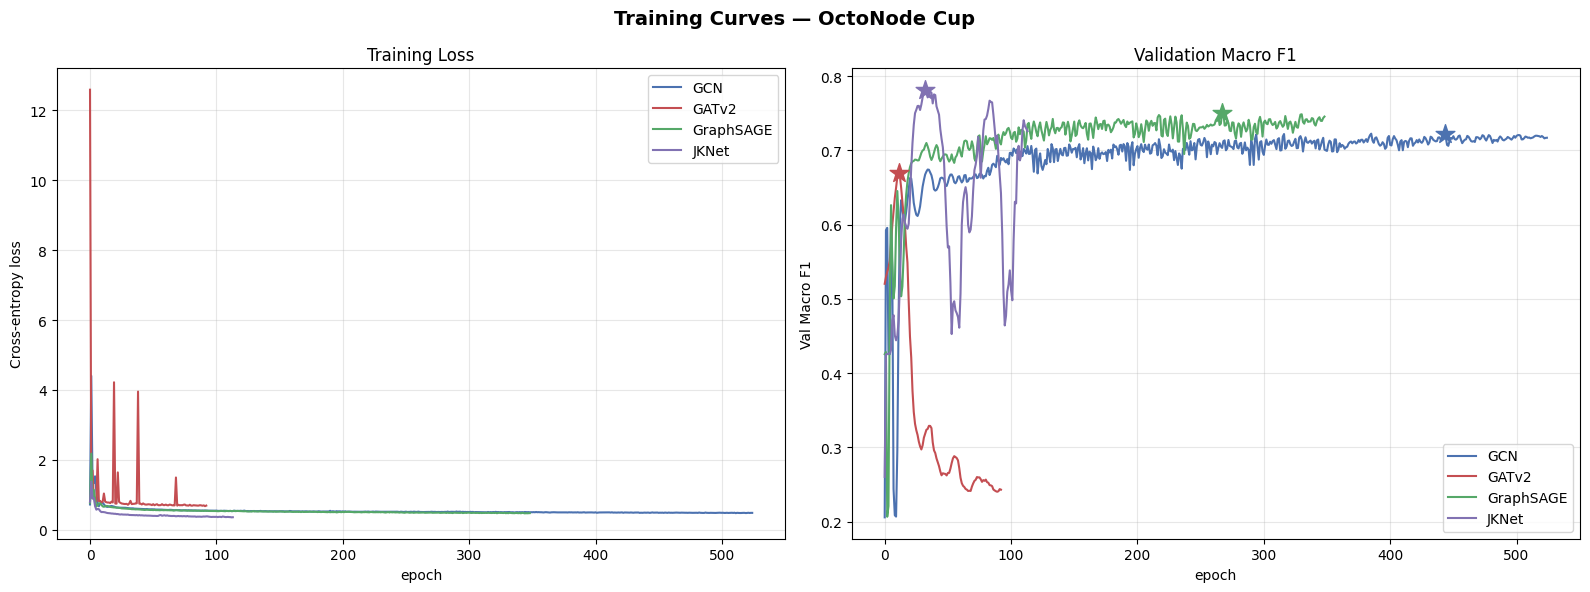

In [57]:
colors = {"GCN": "#4C72B0", "GATv2": "#C44E52","GraphSAGE": "#55A868", "JKNet": "#8172B2"}
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Training Curves — OctoNode Cup", fontsize=14, fontweight="bold")
for name, hist in MODEL_HISTORIES.items():
    axes[0].plot(hist["loss"],   label=name, color=colors[name], lw=1.5)
    axes[1].plot(hist["val_f1"], label=name, color=colors[name], lw=1.5)

for name, hist in MODEL_HISTORIES.items():
    best_ep  = int(np.argmax(hist["val_f1"]))
    best_val = max(hist["val_f1"])
    axes[1].scatter(best_ep, best_val, color=colors[name],marker="*", s=200, zorder=5)

axes[0].set_xlabel("epoch"); axes[0].set_ylabel("Cross-entropy loss")
axes[0].set_title("Training Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_xlabel("epoch"); axes[1].set_ylabel("Val Macro F1")
axes[1].set_title("Validation Macro F1")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [64]:
y_val_true_np = data.y[data.val_mask].cpu().numpy()

for name, model in TRAINED_MODELS.items():
    model.eval()
    with torch.no_grad():
        logits = model(data.x.to(device), data.edge_index.to(device))
        preds = logits.argmax(dim=1)
    val_pred_np = preds[data.val_mask].cpu().numpy()
    val_preds[name] = val_pred_np
    f1 = macro_f1(val_pred_np, y_val_true_np)
    acc = accuracy_score(y_val_true_np, val_pred_np)

    print(f"\n--- {name} ---")
    print(f"Macro F1 = {f1:.4f}  |  Accuracy = {acc:.4f}")
    print(classification_report(
        y_val_true_np, val_pred_np,
        target_names=["ML Dev (0)", "Web Dev (1)"],
        digits=3
    ))


--- GCN ---
Macro F1 = 0.7226  |  Accuracy = 0.7674
              precision    recall  f1-score   support

  ML Dev (0)      0.884     0.789     0.834      4469
 Web Dev (1)      0.539     0.705     0.611      1563

    accuracy                          0.767      6032
   macro avg      0.712     0.747     0.723      6032
weighted avg      0.795     0.767     0.776      6032


--- GATv2 ---
Macro F1 = 0.6695  |  Accuracy = 0.7399
              precision    recall  f1-score   support

  ML Dev (0)      0.834     0.811     0.822      4469
 Web Dev (1)      0.498     0.537     0.517      1563

    accuracy                          0.740      6032
   macro avg      0.666     0.674     0.670      6032
weighted avg      0.747     0.740     0.743      6032


--- GraphSAGE ---
Macro F1 = 0.7508  |  Accuracy = 0.8024
              precision    recall  f1-score   support

  ML Dev (0)      0.880     0.849     0.864      4469
 Web Dev (1)      0.608     0.671     0.637      1563

    accuracy   

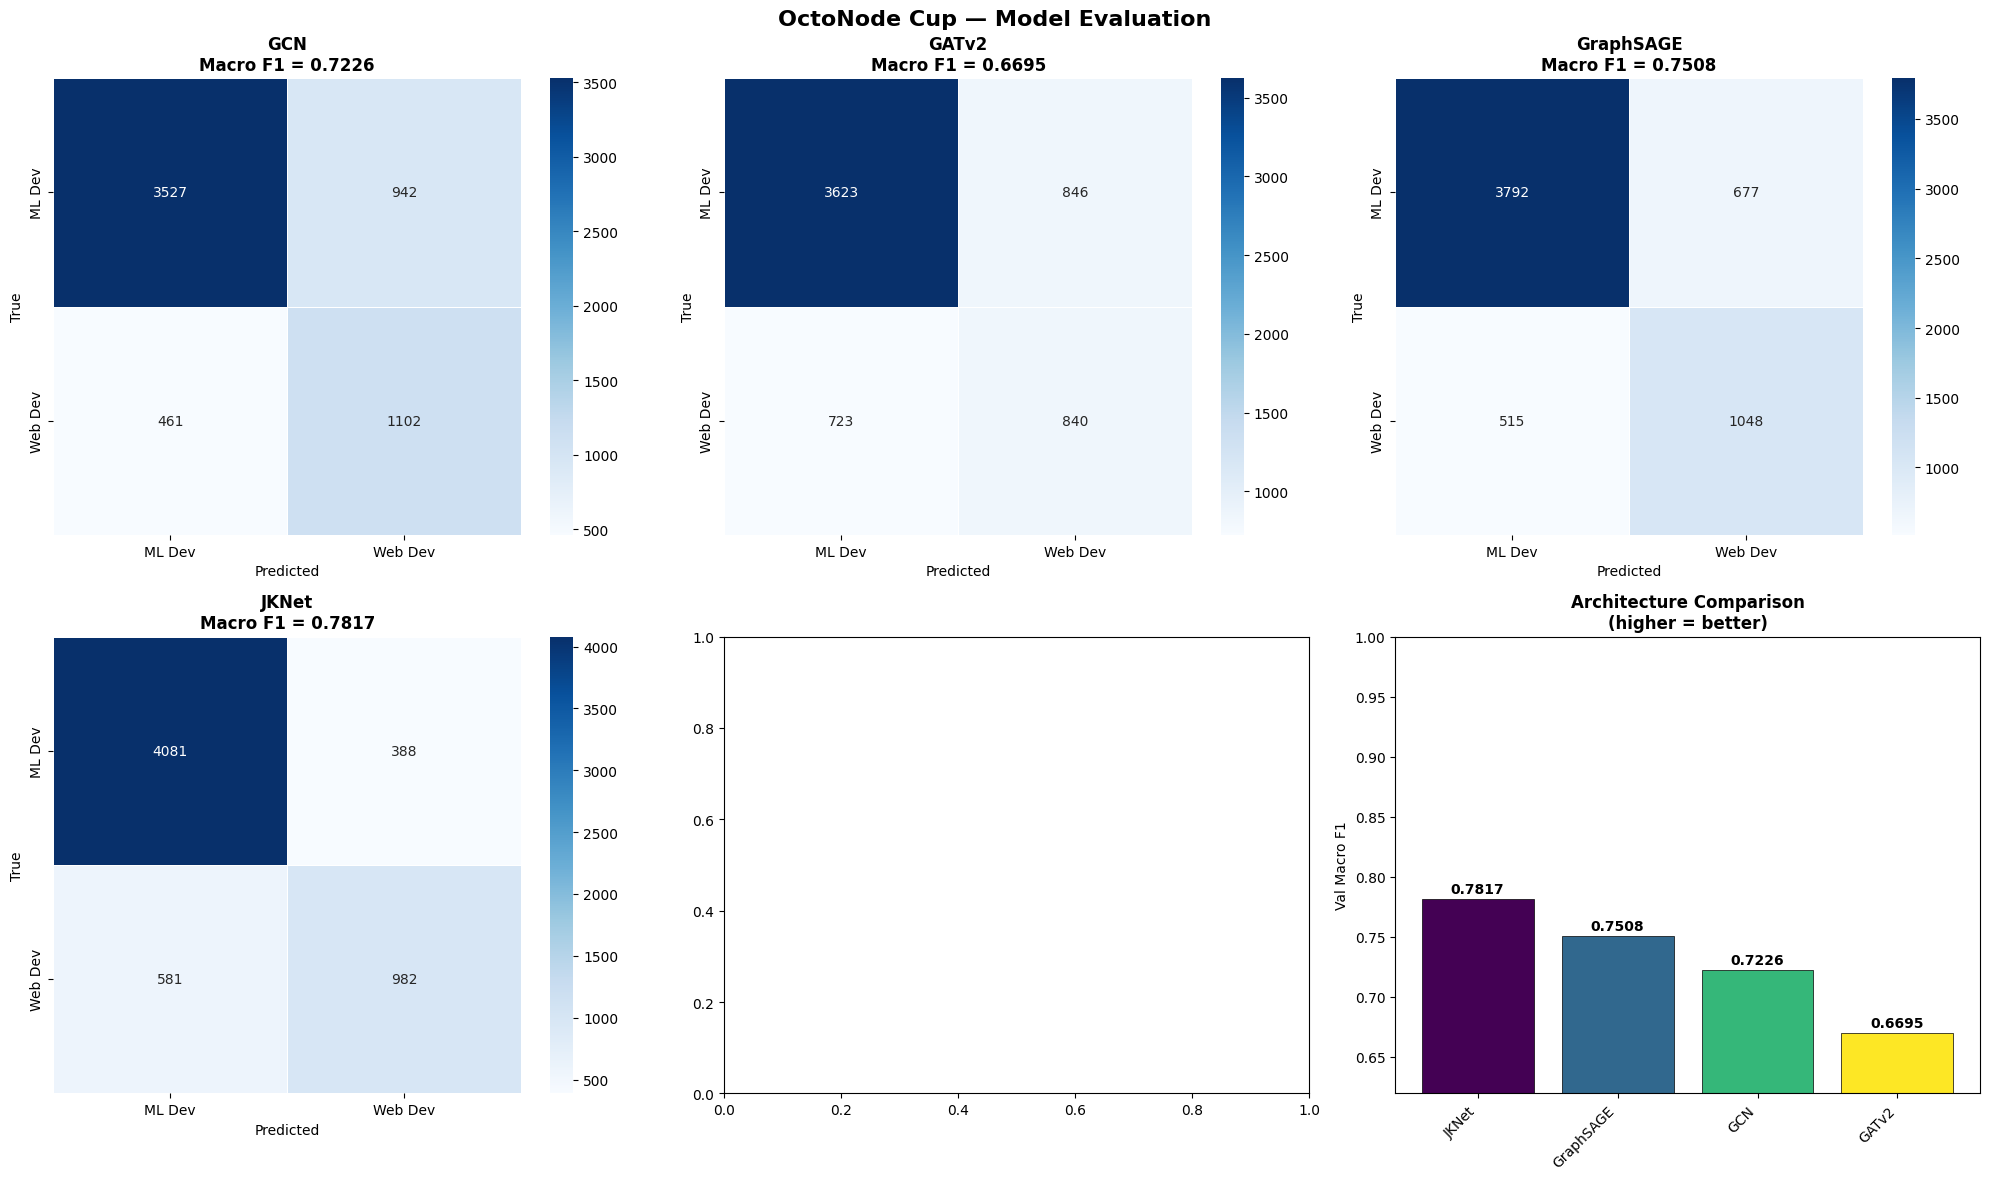

In [72]:

y_val_true_np = y_val_true.cpu().numpy() if torch.is_tensor(y_val_true) else y_val_true
processed_preds = {}
for name, p in val_preds.items():
    processed_preds[name] = p.cpu().numpy() if torch.is_tensor(p) else p

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("OctoNode Cup — Model Evaluation", fontsize=16, fontweight="bold")

for idx, (name, preds_np) in enumerate(processed_preds.items()):
    if idx >= 6: break
    ax_row, ax_col = divmod(idx, 3)
    ax = axes[ax_row][ax_col]

    cm = confusion_matrix(y_val_true_np, preds_np)
    f1 = macro_f1(preds_np, y_val_true_np)

    sns.heatmap(cm, ax=ax, annot=True, fmt="d", cmap="Blues",
                xticklabels=["ML Dev", "Web Dev"],
                yticklabels=["ML Dev", "Web Dev"],
                linewidths=0.5)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{name}\nMacro F1 = {f1:.4f}", fontweight="bold")
ax_bar = axes[1][2]

all_f1s = {n: macro_f1(p, y_val_true_np) for n, p in processed_preds.items()}
sorted_names = sorted(all_f1s, key=lambda n: -all_f1s[n])

colors_list = plt.cm.viridis(np.linspace(0, 1, len(sorted_names)))

bars = ax_bar.bar(sorted_names, [all_f1s[n] for n in sorted_names],
                   color=colors_list, edgecolor="black", linewidth=0.5)

ax_bar.set_ylabel("Val Macro F1")
ax_bar.set_title("Architecture Comparison\n(higher = better)", fontweight="bold")
ax_bar.set_ylim(min(all_f1s.values()) - 0.05, 1.0)
plt.setp(ax_bar.get_xticklabels(), rotation=45, ha="right")

for bar in bars:
    yval = bar.get_height()
    ax_bar.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.4f}",
                ha="center", fontweight="bold", fontsize=10)

plt.tight_layout()
plt.show()


# Producing Submission with JKNet

In [73]:
model

JKNet(
  (convs): ModuleList(
    (0): SAGEConv(42, 256, aggr=mean)
    (1-3): 3 x SAGEConv(256, 256, aggr=mean)
  )
  (bns): ModuleList(
    (0-3): 4 x BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (jk): JumpingKnowledge(max)
  (lin): Linear(in_features=256, out_features=2, bias=True)
)

In [84]:
jk.eval()

with torch.no_grad():
    logits = jk(data.x.to(device), data.edge_index.to(device))
    all_preds = logits.argmax(dim=1)

test_preds = all_preds[data.test_mask.to(device)].cpu().numpy()
submission = pd.DataFrame({
    'id': data.test_ids.cpu().numpy(),
    'ml_target': test_preds
})

submission.to_csv('submission.csv', index=False)

submission.head()

,id,ml_target
0,30159,0
1,30160,0
2,30161,0
3,30162,0
4,30163,0


In [81]:
jk

JKNet(
  (convs): ModuleList(
    (0): SAGEConv(42, 256, aggr=mean)
    (1-3): 3 x SAGEConv(256, 256, aggr=mean)
  )
  (bns): ModuleList(
    (0-3): 4 x BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (jk): JumpingKnowledge(max)
  (lin): Linear(in_features=256, out_features=2, bias=True)
)

In [ ]:
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')
print('afran')